In [40]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_swiss_roll
import torch

In [43]:
n_samples = 5000
data, _ = make_swiss_roll(n_samples)

In [44]:
data.shape

(5000, 3)

In [45]:
data = data[:, [2, 0]] / 10 # Use only two dimensions for visualization
data = data * np.array([1, -1])
data = torch.from_numpy(data).float()

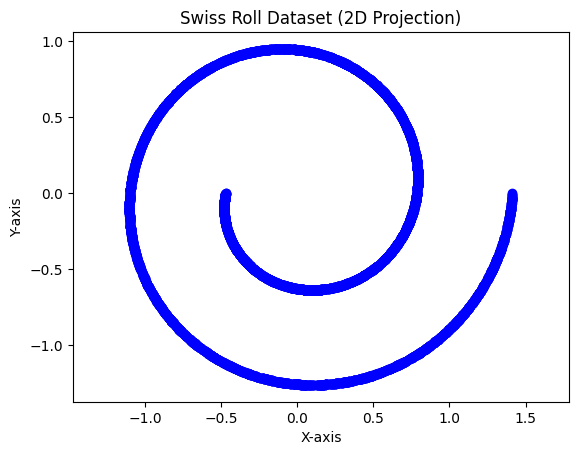

In [46]:
plt.scatter(data[:, 0], data[:, 1], c='blue')
plt.xlim([-2, 2])
plt.ylim([-2, 2])
plt.title('Swiss Roll Dataset (2D Projection)')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.axis('equal')
plt.show()

In [51]:
def forward_process(data, T, betas):
    for t in range(T):
        beta_t = betas[t]
        mu = data * torch.sqrt(1 - beta_t)
        std = torch.sqrt(beta_t)
        # Sample from q(x_t | x_{t-1})
        data = mu + torch.randn_like(data) * std
    return data

In [52]:
T = 40
betas = torch.sigmoid(torch.linspace(-18, 10, T)) * (3e-1 - 1e-5) + 1e-5
xT = forward_process(data, T, betas)

In [53]:
print(xT.mean(0))
print(xT.std(0))

tensor([-0.0244, -0.0227])
tensor([1.0061, 0.9835])


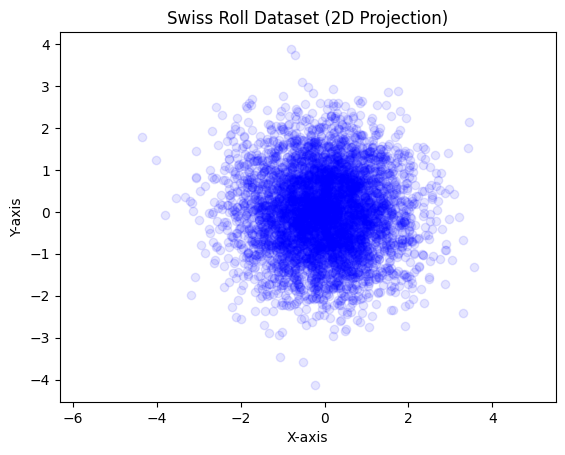

In [54]:
plt.scatter(xT[:, 0], xT[:, 1], c='blue', alpha=0.1)
plt.xlim([-2, 2])
plt.ylim([-2, 2])
plt.title('Swiss Roll Dataset (2D Projection)')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.axis('equal')
plt.show()

In [ ]:
class DiffusionModel(torch.nn.Module):
    def __init__(self, T):
        super(DiffusionModel, self).__init__()
        self.T = T
        self.betas = torch.sigmoid(torch.linspace(-18, 10, T)) * (3e-1 - 1e-5) + 1e-5
        self.alphas = 1 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)

    def forward_process(self, x0, t=40):
        assert t > 0, "t must be greater than 0"
        t = t - 1  # Adjust for 0-based indexing
        mu = torch.sqrt(self.alpha_bars[t-1]) * x0
        std = torch.sqrt(1 - self.alpha_bars[t])
        epsilon = torch.randn_like(x0)  # Sample noise
        xt = mu + std * epsilon
        return xt
        